# BIM KPI Dashboard — Construction + Facility (33 KPIs)

건설 관리 14개 + 시설 관리 17개 + 공통 2개 = **33개 KPI** 를 4개 레벨 (객체, 존, 파이프라인, 플랜트) 에서 시각화합니다.

1. Plant overview — 전체 요약 카드
2. Equipment criticality — 장비 임계도 공간 분포
3. Maintenance accessibility — 유지보수 접근성 히트맵
4. Valve isolation — 격리 구간 분석
5. Corrosion risk — 부식 리스크 (파이프라인 레벨)
6. Zone comparison — 존별 복합 KPI 비교

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from bimkg import config
from bimkg.analytics.metrics import build_physical_graph
from bimkg.analytics.zones import assign_louvain_zones
from bimkg.analytics.precedence import build_precedence_dag, find_longest_chain
from bimkg.analytics.kpi import (
    compute_equipment_criticality, compute_accessibility_index,
    compute_corrosion_risk, compute_valve_isolation,
    compute_zone_kpis, compute_pipeline_kpis, compute_plant_kpis,
)

sns.set_theme(style="whitegrid", font_scale=1.0)
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

gold = pd.read_parquet(config.ENRICHED_OBJECTS)
adj = pd.read_parquet(config.ENRICHED_ADJACENCY_SYM)
G = build_physical_graph(gold, adj)
zone_map = assign_louvain_zones(G, resolution=3.0)
gold["zone_id"] = gold["object_id"].map(zone_map)
phys = gold[gold["graph_participant"] == True].copy()

# Compute all KPIs
crit = compute_equipment_criticality(gold, adj)
access = compute_accessibility_index(gold, adj)
corr = compute_corrosion_risk(gold)
valves = compute_valve_isolation(gold, adj)

obj_kpis = pd.DataFrame({"object_id": gold["object_id"]})
for s in [crit, access, corr]:
    df = s.reset_index(); df.columns = ["object_id", s.name]
    obj_kpis = obj_kpis.merge(df, on="object_id", how="left")
obj_kpis = obj_kpis.fillna(0)

zone_kpis = compute_zone_kpis(gold, zone_map, obj_kpis)
pipe_kpis = compute_pipeline_kpis(gold, zone_map, valves)
dag = build_precedence_dag(gold, adj, zone_col="zone_id", adjacency_tier="strong_medium")
chain = find_longest_chain(dag)
plant = compute_plant_kpis(gold, zone_kpis, pipe_kpis, len(chain))

# Merge object KPIs back to phys for plotting
phys = phys.merge(obj_kpis, on="object_id", how="left")
print("KPIs computed. Ready for visualization.")

KPIs computed. Ready for visualization.


## 1. Plant Overview

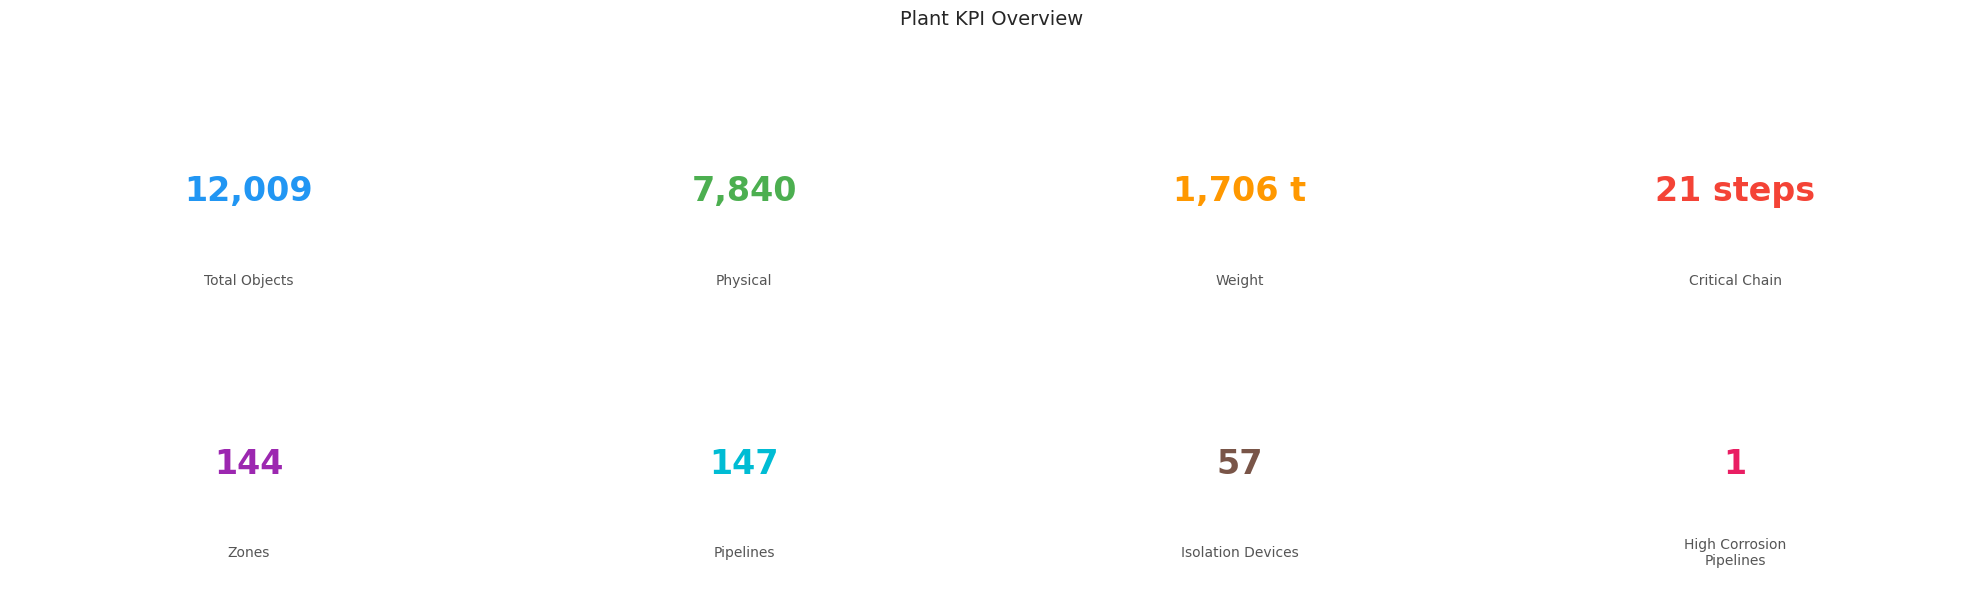

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(20, 6))
cards = [
    ("Total Objects", f"{plant['total_objects']:,}", "#2196F3"),
    ("Physical", f"{plant['total_physical_objects']:,}", "#4CAF50"),
    ("Weight", f"{plant['total_weight_tonnes']:,.0f} t", "#FF9800"),
    ("Critical Chain", f"{plant['critical_chain_length']} steps", "#F44336"),
    ("Zones", f"{len(zone_kpis)}", "#9C27B0"),
    ("Pipelines", f"{len(pipe_kpis)}", "#00BCD4"),
    ("Isolation Devices", f"{len(valves)}", "#795548"),
    ("High Corrosion\nPipelines", f"{plant['high_corrosion_pipelines']}", "#E91E63"),
]
for ax, (title, value, color) in zip(axes.flat, cards):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.text(0.5, 0.55, value, ha="center", va="center", fontsize=24, fontweight="bold", color=color)
    ax.text(0.5, 0.2, title, ha="center", va="center", fontsize=10, color="#555")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

plt.suptitle("Plant KPI Overview", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "05_s1_plant_overview.png", dpi=300, bbox_inches="tight")
plt.show()

### 해석: Plant Overview

| 카드 | 값 | 의미 |
|------|------|------|
| **Total Objects 12,009** | 원본 전체 객체 수. 여기에는 물리 부품, 계층 노드, 분석 볼륨이 모두 포함됨 |
| **Physical 7,840** | 실제 시공/유지보수 대상. 나머지 4,169 는 계층 컨테이너(3,353) + parent box(448) + 분석 볼륨(145) + placeholder(223) |
| **Weight 1,706 t** | 물리 객체의 dry weight 합산. 42.8% 만 무게 데이터가 있으므로 **실제 총중량은 이보다 클 수 있음** |
| **Critical Chain 21 steps** | Strong+Medium adjacency 기반 최소 순차 설치 단계. "아무리 빨라도 21번은 기다려야 한다" |
| **Zones 144** | Louvain 커뮤니티 (resolution=3.0). M3 parent box 제거 후 세밀해짐 (이전 29존 → 144존) |
| **Pipelines 147** | 고유 파이프라인 수. 각각 독립적 시공/유지보수 단위 |
| **Isolation Devices 57** | Blind Flange + Spectacle blind. 이 플랜트에 Valve 객체는 없음 — DXTnavis 추출 범위 한계 가능성. **실제 Valve 가 있다면 이 수치는 크게 늘어남** |
| **High Corrosion Pipelines 1** | pressure × temperature × material factor 가 0.7 이상인 파이프라인. **데이터 한계**: 28개 객체만 pressure+temperature 보유 → 과소평가됨 |

**데이터 한계 주의**: Weight (42.8%), Pressure/Temperature (19.6%), Valve (0%) — 이 KPI 들은 데이터 커버리지가 올라가면 값이 변합니다.

## 2. Equipment Criticality — 공간 분포

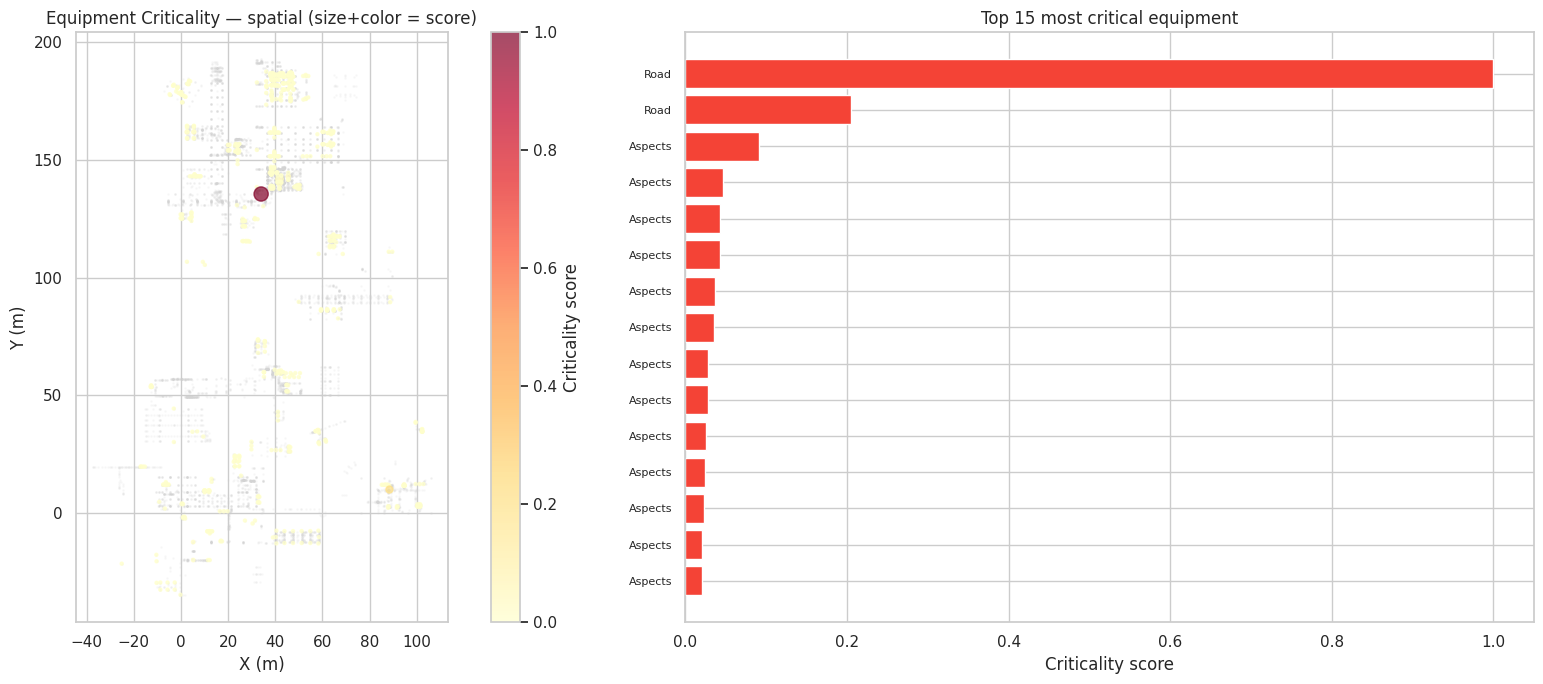

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: top view — criticality heatmap
eqp = phys[phys["refined_class"] == "Equipment"]
sc = axes[0].scatter(phys["centroid_x"], phys["centroid_y"], s=1, alpha=0.1, c="lightgray")
sc2 = axes[0].scatter(eqp["centroid_x"], eqp["centroid_y"],
                       c=eqp["equipment_criticality_score"], cmap="YlOrRd",
                       s=eqp["equipment_criticality_score"] * 100 + 5, alpha=0.7)
plt.colorbar(sc2, ax=axes[0], label="Criticality score")
axes[0].set_xlabel("X (m)"); axes[0].set_ylabel("Y (m)")
axes[0].set_title("Equipment Criticality — spatial (size+color = score)")
axes[0].set_aspect("equal")

# Right: top 15 most critical equipment
top_crit = phys[phys["refined_class"] == "Equipment"].nlargest(15, "equipment_criticality_score")
labels = [str(row["display_name"])[:30] if pd.notna(row["display_name"]) else row["object_id"][:12]
          for _, row in top_crit.iterrows()]
axes[1].barh(range(len(top_crit)), top_crit["equipment_criticality_score"], color="#F44336")
axes[1].set_yticks(range(len(top_crit)))
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_xlabel("Criticality score")
axes[1].set_title("Top 15 most critical equipment")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES / "05_s2_equipment_criticality.png", dpi=300, bbox_inches="tight")
plt.show()

### 해석: Equipment Criticality

**읽는 법**:
- 왼쪽 (공간 분포): 큰 빨간 점 = 임계도 높은 장비. 위치가 플랜트 내 어디인지 보여줌
- 오른쪽 (Top 15): 가장 고장 시 파급이 큰 장비 목록

**산출 방식**: `criticality = degree centrality × (1 + 인접 파이프라인 수)`. 이웃이 많고(degree) + 여러 파이프라인에 걸쳐있으면(교차점) 고장 시 영향 범위가 넓음.

**건설 관점**: 이 장비들은 시공 시 가장 먼저 설치해야 하고, 주변에 충분한 작업 공간을 확보해야 함.
**시설 관점**: 이 장비들의 예방 정비 주기를 단축하고, 예비 부품을 우선 확보해야 함. 고장 시 여러 파이프라인이 동시에 영향받으므로 셧다운 범위가 넓어짐.

**한계**: degree 는 AABB 기반 adjacency 에서 계산됨. Strong tier (touch) 만으로 재계산하면 더 정확한 물리적 임계도가 나올 수 있음.

## 3. Maintenance Accessibility + Valve Isolation

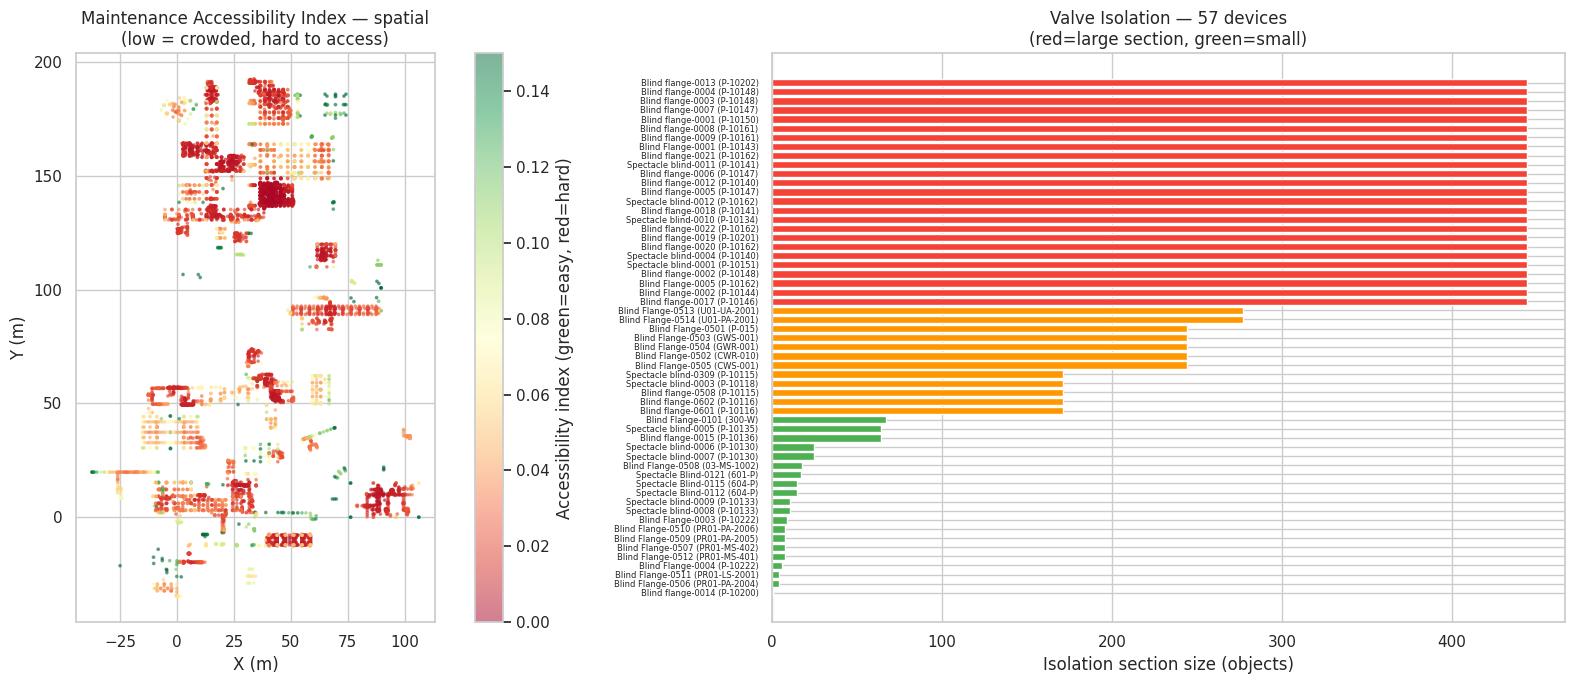

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: accessibility heatmap (top view)
sc = axes[0].scatter(phys["centroid_x"], phys["centroid_y"],
                     c=phys["maintenance_accessibility_index"], cmap="RdYlGn",
                     s=3, alpha=0.5, vmin=0, vmax=0.15)
plt.colorbar(sc, ax=axes[0], label="Accessibility index (green=easy, red=hard)")
axes[0].set_xlabel("X (m)"); axes[0].set_ylabel("Y (m)")
axes[0].set_title("Maintenance Accessibility Index — spatial\n(low = crowded, hard to access)")
axes[0].set_aspect("equal")

# Right: valve isolation sections
if not valves.empty:
    valve_data = valves.merge(gold[["object_id", "display_name", "sp3d_pipeline", "centroid_z"]], on="object_id")
    valve_data = valve_data.sort_values("isolation_section_size", ascending=False)
    labels = [f"{str(row['display_name'])[:20]} ({str(row['sp3d_pipeline'])[:12]})"
              for _, row in valve_data.iterrows()]
    colors = ["#F44336" if s > 300 else "#FF9800" if s > 100 else "#4CAF50"
              for s in valve_data["isolation_section_size"]]
    axes[1].barh(range(len(valve_data)), valve_data["isolation_section_size"], color=colors)
    axes[1].set_yticks(range(len(valve_data)))
    axes[1].set_yticklabels(labels, fontsize=6)
    axes[1].set_xlabel("Isolation section size (objects)")
    axes[1].set_title(f"Valve Isolation — {len(valve_data)} devices\n(red=large section, green=small)")
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, "No isolation valves found", ha="center", va="center")
    axes[1].set_title("Valve Isolation")

plt.tight_layout()
plt.savefig(FIGURES / "05_s3_accessibility_isolation.png", dpi=300, bbox_inches="tight")
plt.show()

### 해석: Accessibility + Valve Isolation

**왼쪽 — 접근성 지수**:
- 색상: 초록 = 주변이 여유 (정비 접근 쉬움), 빨강 = 주변이 밀집 (정비 어려움)
- 산출: `1 / (1 + 5m 반경 내 객체 수)`. 값이 0.1 이하면 10개 이상의 객체가 5m 안에 밀집
- **해석**: 대부분이 빨간색 → 이 플랜트는 전반적으로 **밀집 배치**. 정비 시 비계 설치, 크레인 접근 경로 확보가 일상적으로 필요한 구조
- **건설 관점**: 밀집 구역에서는 시공 순서가 더 엄격해야 함 — 나중에 설치하는 객체에 접근하기 어려워지므로
- **시설 관점**: 접근성이 낮은 구역의 장비는 예방 정비가 어려움 → 검사 주기를 단축하거나 원격 모니터링 도입을 고려

**오른쪽 — 격리 장치**:
- 각 막대 = 하나의 Blind Flange 또는 Spectacle blind
- 막대 길이 = 이 장치가 잠겼을 때 격리되는 객체 수
- 색상: 빨강 (>300 객체) = 큰 구간 → 잠그면 넓은 범위 영향, 초록 (<100) = 작은 구간 → 정밀 격리 가능
- **시설 관점**: 빨간 격리 장치 = 셧다운 시 영향 범위가 넓어 계획 수립이 복잡. 초록 = 부분 격리 가능
- **주의**: Valve 객체가 이 데이터에 없으므로 실제 격리 장치 수는 훨씬 많을 것. Blind Flange 는 영구 격리에 가까운 장치이고, 실제 운전 중 격리는 밸브로 수행

## 4. Zone Comparison — 건설 + 시설 복합 KPI

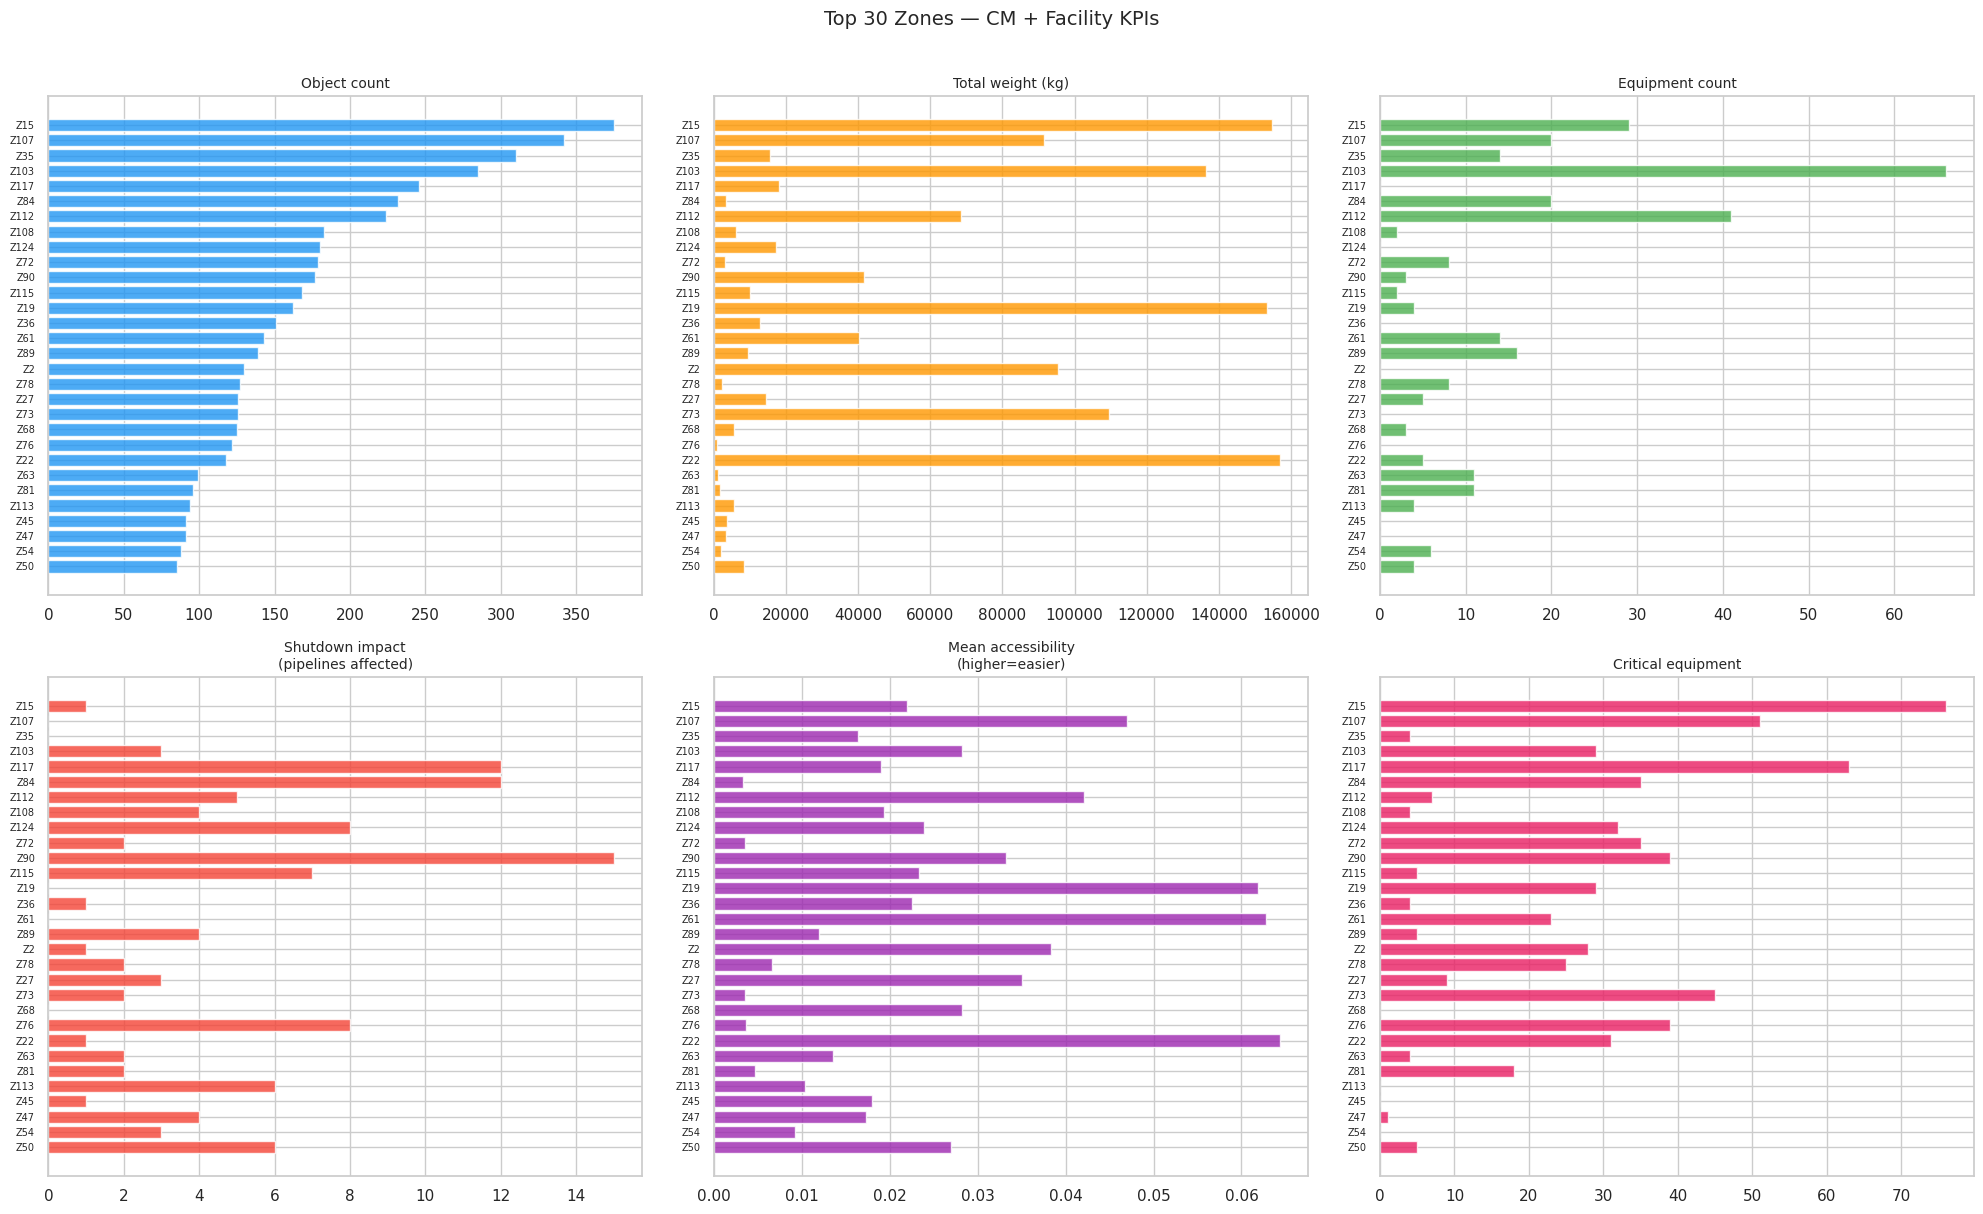

In [5]:
# Top 30 zones by object count
top30z = zone_kpis.nlargest(30, "zone_object_count")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
zone_labels = [f"Z{int(z)}" for z in top30z.index]

metrics = [
    ("zone_object_count", "Object count", "#2196F3"),
    ("zone_total_weight_kg", "Total weight (kg)", "#FF9800"),
    ("zone_equipment_count", "Equipment count", "#4CAF50"),
    ("zone_shutdown_impact", "Shutdown impact\n(pipelines affected)", "#F44336"),
    ("zone_mean_accessibility", "Mean accessibility\n(higher=easier)", "#9C27B0"),
    ("zone_critical_equipment_count", "Critical equipment", "#E91E63"),
]

for ax, (col, title, color) in zip(axes.flat, metrics):
    vals = top30z[col].fillna(0)
    ax.barh(range(len(top30z)), vals, color=color, alpha=0.8)
    ax.set_yticks(range(len(top30z)))
    ax.set_yticklabels(zone_labels, fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()

plt.suptitle("Top 30 Zones — CM + Facility KPIs", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "05_s4_zone_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### 해석: Zone Comparison

6개 차트를 가로로 비교하면 **각 존의 건설+시설 특성**이 한눈에 보입니다.

**읽는 법**: 같은 Y 축 행이 같은 존. 6개 지표를 가로로 읽으면 그 존의 프로필이 됩니다.

| 차트 | 높으면 | 건설/시설 판단 |
|------|--------|---------------|
| **Object count** | 존이 큼 → 작업 기간 길어짐 | 건설: 크루 추가 배치 고려 |
| **Total weight** | 무거움 → 양중 장비 필요 | 건설: 크레인 용량/횟수 계획 |
| **Equipment count** | 장비 많음 → 장비 설치가 존의 주요 작업 | 건설: 장비 먼저 시공 |
| **Shutdown impact** | 파이프라인 많이 걸침 → 이 존 셧다운 시 영향 큼 | 시설: 셧다운 범위 계획 시 우선 검토 |
| **Mean accessibility** | 높으면 여유, 낮으면 밀집 | 시설: 낮은 존 = 정비 비용 ↑ |
| **Critical equipment** | 많으면 이 존에 핵심 장비 집중 | 시설: 예방 정비 리소스 집중 |

**패턴 찾기**:
- "무겁고 + 장비 많고 + 접근성 낮은" 존 = **건설과 시설 모두 어려운 존**. 시공 기간과 정비 비용이 높을 것
- "가볍고 + 접근성 높고 + 셧다운 영향 적은" 존 = 비교적 독립적이고 관리가 쉬운 존

## 5. Pipeline KPI Comparison — 부식 리스크 + 격리 + 크기

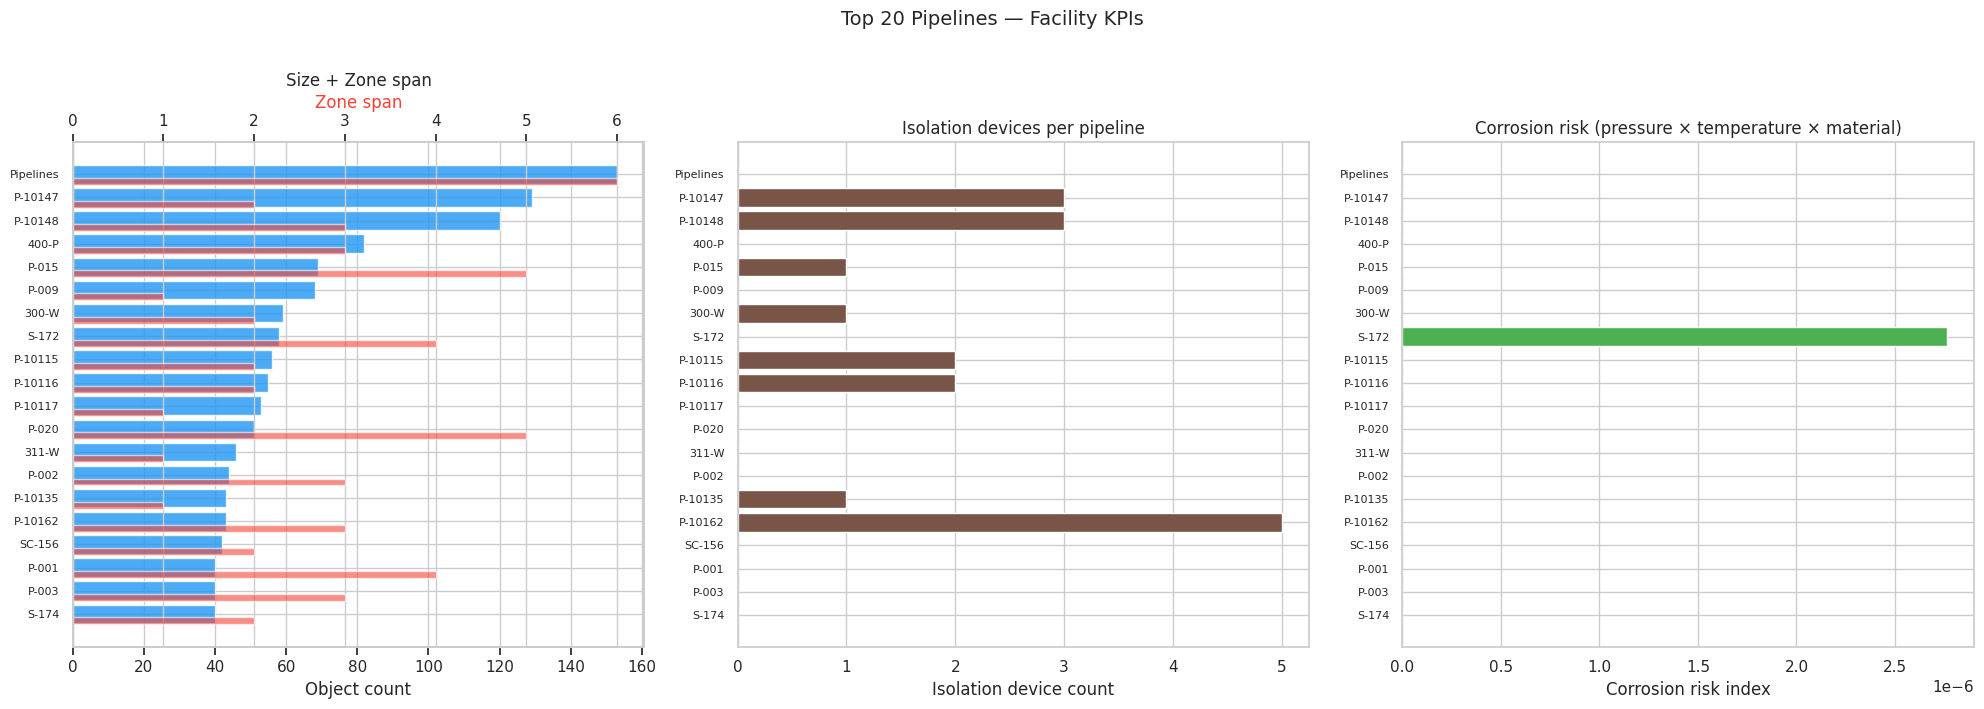

Pipelines with isolation devices: 40 / 147
Pipelines with corrosion risk > 0: 4
Max zone span: 6 zones


In [6]:
top20p = pipe_kpis.nlargest(20, "pipeline_object_count")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
pipe_labels = [str(p)[:15] for p in top20p.index]

# Object count + zone span
ax = axes[0]
ax.barh(range(len(top20p)), top20p["pipeline_object_count"], color="#2196F3", alpha=0.8, label="Objects")
ax2 = ax.twiny()
ax2.barh([i + 0.3 for i in range(len(top20p))], top20p["pipeline_zone_span"],
         height=0.3, color="#F44336", alpha=0.6, label="Zone span")
ax.set_yticks(range(len(top20p)))
ax.set_yticklabels(pipe_labels, fontsize=8)
ax.set_xlabel("Object count"); ax2.set_xlabel("Zone span", color="#F44336")
ax.set_title("Size + Zone span")
ax.invert_yaxis()

# Valve count + isolation sections
ax = axes[1]
ax.barh(range(len(top20p)), top20p["pipeline_valve_count"].fillna(0), color="#795548")
ax.set_yticks(range(len(top20p)))
ax.set_yticklabels(pipe_labels, fontsize=8)
ax.set_xlabel("Isolation device count")
ax.set_title("Isolation devices per pipeline")
ax.invert_yaxis()

# Corrosion risk
ax = axes[2]
cr = top20p["pipeline_corrosion_risk"].fillna(0)
colors = ["#F44336" if v > 0.5 else "#FF9800" if v > 0.1 else "#4CAF50" for v in cr]
ax.barh(range(len(top20p)), cr, color=colors)
ax.set_yticks(range(len(top20p)))
ax.set_yticklabels(pipe_labels, fontsize=8)
ax.set_xlabel("Corrosion risk index")
ax.set_title("Corrosion risk (pressure × temperature × material)")
ax.invert_yaxis()

plt.suptitle("Top 20 Pipelines — Facility KPIs", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "05_s5_pipeline_kpis.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary
print(f"Pipelines with isolation devices: {(pipe_kpis['pipeline_valve_count'] > 0).sum()} / {len(pipe_kpis)}")
print(f"Pipelines with corrosion risk > 0: {(pipe_kpis['pipeline_corrosion_risk'] > 0).sum()}")
print(f"Max zone span: {pipe_kpis['pipeline_zone_span'].max()} zones")

### 해석: Pipeline KPIs

**왼쪽 — 크기 + 존 범위**:
- 파란 막대 = 파이프라인 내 객체 수 (큰 파이프라인 = 긴 배관)
- 빨간 막대 = 걸치는 존 수 (넓게 퍼진 파이프라인 = 시공 조율 복잡)
- **해석**: 객체 수가 많으면서 존 범위도 넓은 파이프라인이 시공과 셧다운 모두에서 가장 관리 어려움

**가운데 — 격리 장치 수**:
- 격리 장치가 0인 파이프라인 = 부분 격리 불가 → **셧다운 시 전체를 한 번에 멈춰야 함**
- 격리 장치가 2개 이상이면 구간별 부분 정비 가능
- **주의**: Valve 미포함 (Blind Flange 만 있음) → 실제 운전 중 격리 능력은 이보다 좋을 것

**오른쪽 — 부식 리스크**:
- 산출: `(mean pressure × mean temperature × material factor) / max`
- 빨강 (>0.5) = 고압+고온 → 부식/열화 가속, 초록 = 저리스크
- **데이터 한계**: pressure+temperature 가 있는 객체가 28개뿐. 대부분 0 으로 나옴
- **다음 단계**: DXTnavis 에서 설계 압력/온도 추출 범위를 넓히면 이 지표의 신뢰도가 올라감

**종합 판단**: 크고 + 넓게 퍼지고 + 격리 장치 없고 + 부식 리스크 높은 파이프라인 → **정비 계획 우선 대상**